# MLflow

MLflow is a centralized experiment tracking platform that solves key challenges in machine learning workflows:

- **Reproducibility**: Share exact parameters with peers to replicate results
- **Model Selection**: Compare architectures and metrics across multiple models
- **Performance Tracking**: Monitor retrained models against previous iterations

**The Problem with Manual Tracking**
Version control commits require careful tagging, and parameter files need documentation for teammates to use—both are error-prone and time-consuming.

**MLflow's Solution**
A tracking server that automatically logs:
- Hyperparameters
- Training/testing data versions
- Model weights
- Accuracy metrics
- Artifacts (plots, saved models)

**Key Benefits**
Multiple users can collaboratively track, compare, and reproduce experiments without manual documentation. This directly answers common ML engineering questions like "Which model is in production?" or "What parameters produced our best results six months ago?"

**Practical Application**
The text demonstrates this through a Jupyter Notebook workflow for income classification—combining exploratory data analysis with automatic MLflow logging to create a structured, shareable experimentation process.

In [1]:
import pandas as pd
import os
from plotnine import ggplot, geom_bar, theme_bw, labs, coord_flip, aes
import time
from IPython.display import display


## Extremely Basic EDA

In [2]:
df = pd.read_csv("data/income_data.csv", index_col=False)

In [3]:
df.head()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country,Target
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Workclass       30162 non-null  object
 1   Education       30162 non-null  object
 2   Marital-Status  30162 non-null  object
 3   Occupation      30162 non-null  object
 4   Relationship    30162 non-null  object
 5   Race            30162 non-null  object
 6   Sex             30162 non-null  object
 7   Native_country  30162 non-null  object
 8   Target          30162 non-null  object
dtypes: object(9)
memory usage: 2.1+ MB


In [5]:
df.describe()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country,Target
count,30162,30162,30162,30162,30162,30162,30162,30162,30162
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22286,9840,14065,4038,12463,25933,20380,27504,22654


In [6]:
# if not os.path.exists("categorical_variable_plots"):
#     os.makedirs("categorical_variable_plots")
# for i in df.iloc[:, :-1].select_dtypes(include="object").columns:
#     print(f"Variable {i}  \n ")
#     print(df[i].value_counts())
#     plot = (
#         ggplot(df)
#         + geom_bar(aes(x=df[i], fill=df.Target), position="fill")
#         + theme_bw()
#         + labs(title=f"Variable {i} ~ Target")
#         + coord_flip()
#     )
#     plot.save(f"categorical_variable_plots/Variable {i}")
#     display(plot)


## Setting Up MLflow

In [7]:
import os

# MinIO credentials (must match what you used in the secret)
os.environ["AWS_ACCESS_KEY_ID"] = "minio"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minio123"

# Point to your MinIO service (ensure port-forward is active)
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"

# (Optional) Disable SSL if using plain HTTP
# os.environ["MLFLOW_S3_IGNORE_TLS"] = "true"


In [8]:
import mlflow
import uuid

**Then we must start a local tracking server by running the `mlflow ui` command which will
create a local tracking server at port 5000. This command needs to be run outside the
notebook. `mlflow ui`**

Or Run mlflow in kubernates.

In [9]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("income-classifier")

<Experiment: artifact_location='s3://mlflow/1', creation_time=1775779461331, experiment_id='1', last_update_time=1775779461331, lifecycle_stage='active', name='income-classifier', tags={}, trace_location=None, workspace='default'>

In [10]:
with mlflow.start_run(run_name=f"eda-{uuid.uuid4()}"):
    for i in (
        df.iloc[:, :-1].select_dtypes(include="object").columns
    ):  # -1 excludes target coloums
        print(f"Variable {i}  \n ")
        print(df[i].value_counts())

        plot = (
            ggplot(df)
            + geom_bar(aes(x=df[i], fill=df.Target), position="fill")
            + theme_bw()
            + labs(title=f"Variable {i} ~ Target")
            + coord_flip()
        )
        # display(plot)
        if not os.path.exists("categorical_variable_plots"):
            os.makedirs("categorical_variable_plots")
        plot.save(f"categorical_variable_plots/Variable {i}")
        mlflow.log_artifacts("categorical_variable_plots")


Variable Workclass  
 
Workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64


/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: categorical_variable_plots/Variable Workclass


Variable Education  
 
Education
HS-grad         9840
Some-college    6678
Bachelors       5044
Masters         1627
Assoc-voc       1307
11th            1048
Assoc-acdm      1008
10th             820
7th-8th          557
Prof-school      542
9th              455
12th             377
Doctorate        375
5th-6th          288
1st-4th          151
Preschool         45
Name: count, dtype: int64


/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: categorical_variable_plots/Variable Education


Variable Marital-Status  
 
Marital-Status
Married-civ-spouse       14065
Never-married             9726
Divorced                  4214
Separated                  939
Widowed                    827
Married-spouse-absent      370
Married-AF-spouse           21
Name: count, dtype: int64


...

Variable Sex  
 
Sex
Male      20380
Female     9782
Name: count, dtype: int64


/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: categorical_variable_plots/Variable Sex


Variable Native_country  
 
Native_country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Columbia                         56
Poland                           56
Haiti                            42
Iran                             42
Taiwan                           42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece               

/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/sharukh/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: categorical_variable_plots/Variable Native_country


🏃 View run eda-d13e619b-ccc6-41b7-abb3-8f024f8044cb at: http://localhost:5000/#/experiments/1/runs/a115907fe2714ffb93d783f215c31305
🧪 View experiment at: http://localhost:5000/#/experiments/1


Output:

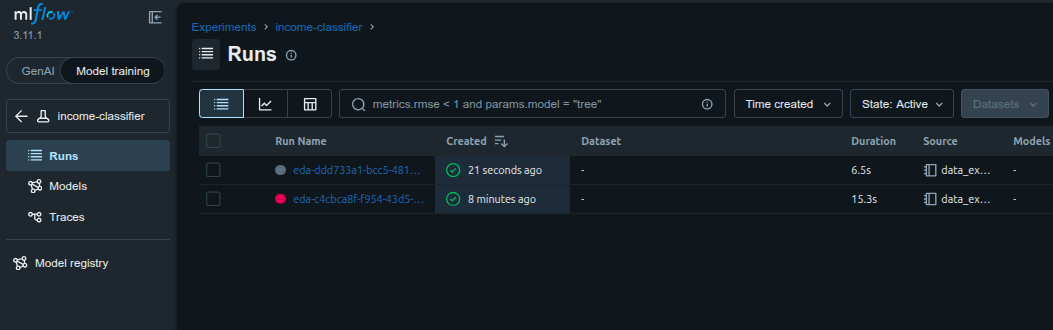

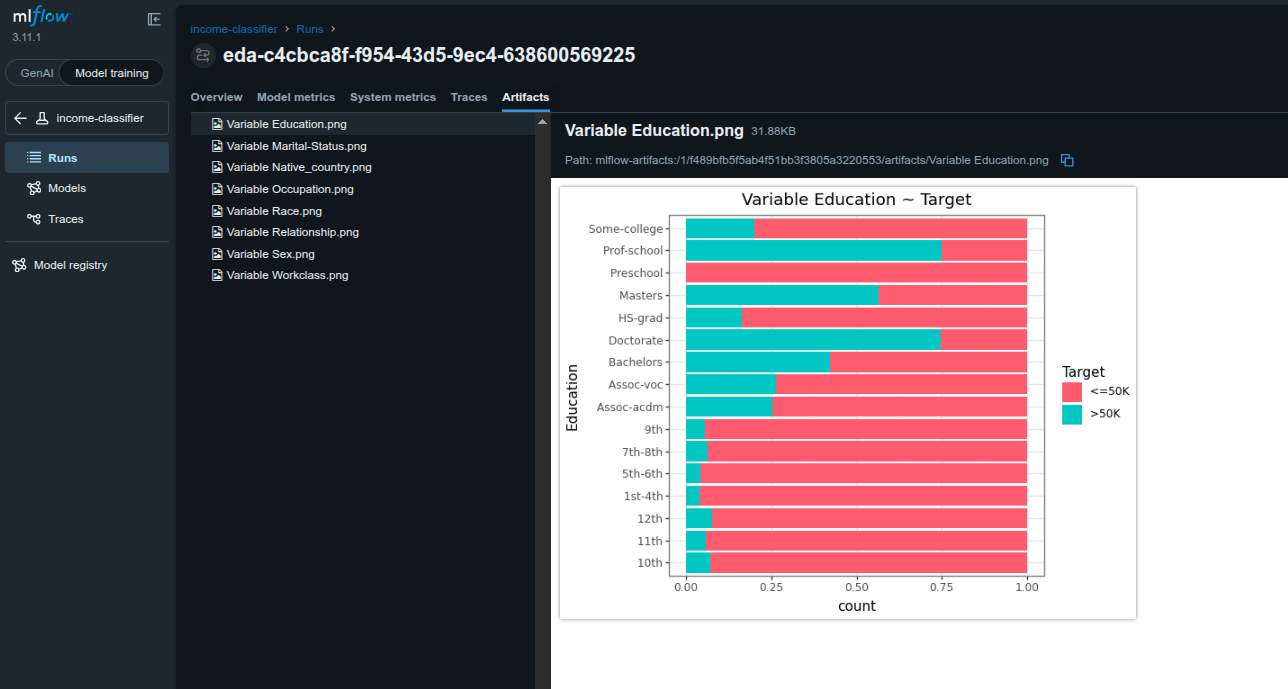

### Model Training

Train Test Split

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pickle

target = df.Target
feature_df = df.drop("Target", axis=1)
# Codifying the predictors and the target
encoder = OneHotEncoder(sparse_output=False, drop="if_binary")
target = encoder.fit_transform(np.array(target).reshape(-1, 1))
dummyfied_df = pd.get_dummies(feature_df, drop_first=True, sparse=False, dtype=float)
col_list = dummyfied_df.columns.to_list()
with open("column_list.pkl", "wb") as f:
    pickle.dump(col_list, f)
X_train, X_test, y_train, y_test = train_test_split(
    dummyfied_df.reindex(columns=col_list, fill_value=0),
    target,
    train_size=0.80,
    shuffle=True,
)

In [12]:
feature_df.head()

,Workclass,Education,Marital-Status,Occupation,Relationship,Race,Sex,Native_country
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba


In [13]:
X_train.head()

,Workclass_ Local-gov,Workclass_ Private,Workclass_ Self-emp-inc,Workclass_ Self-emp-not-inc,Workclass_ State-gov,Workclass_ Without-pay,Education_ 11th,Education_ 12th,Education_ 1st-4th,Education_ 5th-6th,...,Native_country_ Portugal,Native_country_ Puerto-Rico,Native_country_ Scotland,Native_country_ South,Native_country_ Taiwan,Native_country_ Thailand,Native_country_ Trinadad&Tobago,Native_country_ United-States,Native_country_ Vietnam,Native_country_ Yugoslavia
18640,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6806,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6932,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3844,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5781,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [13]:
y_train

array([[1.],
       [1.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(24129, 1))

Utilities

**MinIO is a lightweight tool that gives you S3-style file storage on your own machine or server.**

👉 In simple terms:

It’s like your own private AWS S3 for storing files (models, images, datasets).

🔹 Why use it with MLflow

MLflow separates storage into:

- **Metadata** → parameters, metrics (small data)
- **Artifacts** → models, plots, files (large data)

👉 MinIO is used to store those **artifacts**: `MLflow tracks experiments + MinIO stores the files`

🔹 When you need it
Working on real projects (not just local)
Multiple users / remote access
Want scalable storage like cloud

In [28]:
from minio import Minio
from io import BytesIO


minioClient = Minio(
    "localhost:9000",
    access_key="minio",  # Use your actual MinIO credentials
    secret_key="minio123",
    secure=False,
)

# Create bucket if it doesn't exist
if not minioClient.bucket_exists("mlflow"):
    minioClient.make_bucket("mlflow")
    print("Bucket 'mlflow' created successfully")
else:
    print("Bucket 'mlflow' already exists")


def save_df_to_minio(df, bucket_name, path):
    """Save DataFrame to MinIO as CSV"""
    csv_bytes = df.to_csv(index=False).encode("utf-8")
    csv_buffer = BytesIO(csv_bytes)

    # Ensure bucket exists before upload
    if not minioClient.bucket_exists(bucket_name):
        minioClient.make_bucket(bucket_name)

    minioClient.put_object(
        bucket_name,  # Fixed: removed f-string wrapper
        path,  # Fixed: removed f-string wrapper
        data=csv_buffer,
        length=len(csv_bytes),
        content_type="text/csv",  # Changed to standard MIME type
    )
    print(f"Saved to s3://{bucket_name}/{path}")


Bucket 'mlflow' already exists


### Training with MLflow

Decision Tree Classifier

- #A Saving the training and test dataframe to MinIO
- #B Converting Pandas dataframe to MLflow dataframe
- #C Logging the MLflow dataframe to MLflow
- #D Train the model
- #E Generate model performance metrics
- #F Logging the performance metric in MLflow
- #G Log the model in MLflow
- #H Log the model parameters in MLflow

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

BUCKET_NAME = "mlflow"


with mlflow.start_run() as run:
    results = pd.DataFrame(
        index=[
            "Roc Auc Score test",
            "Accuracy score train",
            "Accuracy Score test",
            "time to fit",
        ]
    )

    tree = DecisionTreeClassifier()
    run_id = run.info.run_id

    # Define paths
    feature_df_path = f"income-classifier-datasets/feature_df-{run_id}.csv"
    train_df_path = f"income-classifier-datasets/train-{run_id}.csv"
    test_df_path = f"income-classifier-datasets/test-{run_id}.csv"

    # Prepare dataframes
    train_df = pd.concat([X_train, pd.Series(y_train.ravel(), name="target")], axis=1)
    test_df = pd.concat([X_test, pd.Series(y_test.ravel(), name="target")], axis=1)

    # Save to MinIO (order matters - save before logging)
    save_df_to_minio(feature_df, BUCKET_NAME, feature_df_path)  # A
    save_df_to_minio(train_df, BUCKET_NAME, train_df_path)
    save_df_to_minio(test_df, BUCKET_NAME, test_df_path)

    # Log datasets to MLflow
    training_dataset = mlflow.data.from_pandas(
        train_df,
        source=f"s3://{BUCKET_NAME}/{train_df_path}",  # B
    )
    test_dataset = mlflow.data.from_pandas(
        test_df, source=f"s3://{BUCKET_NAME}/{test_df_path}"
    )
    feature_dataset = mlflow.data.from_pandas(
        feature_df, source=f"s3://{BUCKET_NAME}/{feature_df_path}"
    )

    mlflow.log_input(training_dataset, context="training")  # C
    mlflow.log_input(test_dataset, context="testing")
    mlflow.log_input(feature_dataset, context="reference")

    # Train model
    tree.fit(X_train, y_train.ravel())  # D

    # Calculate metrics
    roc_auc_score_train = roc_auc_score(
        y_train == 1, tree.predict_proba(X_train)[:, 1]
    )  # E
    roc_auc_score_test = roc_auc_score(y_test == 1, tree.predict_proba(X_test)[:, 1])
    training_accuracy = tree.score(X_train, y_train)
    test_accuracy = tree.score(X_test, y_test)

    # Log to MLflow
    mlflow.log_metric("roc_auc_score_train", roc_auc_score_train)  # F
    print(f"Roc Auc Score train: {roc_auc_score_train}\n")

    mlflow.log_metric("roc_auc_score_test", roc_auc_score_test)
    print(f"Roc Auc Score test: {roc_auc_score_test}\n")

    mlflow.log_metric("training_accuracy", training_accuracy)
    print(f"Accuracy train: {training_accuracy}")

    mlflow.log_metric("test_accuracy", test_accuracy)
    print(f"Accuracy test: {test_accuracy}")

    mlflow.sklearn.log_model(tree, name="income-classifier")  # G
    mlflow.log_params(tree.get_params())  # H

Saved to s3://mlflow/income-classifier-datasets/feature_df-66fa623673db44ae95c60d3fc20417e8.csv
Saved to s3://mlflow/income-classifier-datasets/train-66fa623673db44ae95c60d3fc20417e8.csv
Saved to s3://mlflow/income-classifier-datasets/test-66fa623673db44ae95c60d3fc20417e8.csv
Roc Auc Score train: 0.932639645463195

Roc Auc Score test: 0.823030043618279

Accuracy train: 0.8634837747109287
Accuracy test: 0.8189955246146196


2026/04/10 03:22:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run bustling-boar-843 at: http://localhost:5000/#/experiments/1/runs/66fa623673db44ae95c60d3fc20417e8
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [29]:
for obj in minioClient.list_objects("mlflow", recursive=True):
    print(obj.object_name)


1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Education.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Marital-Status.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Native_country.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Occupation.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Race.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Relationship.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Sex.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Workclass.png
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/MLmodel
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/conda.yaml
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/model.pkl
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/python_env.yaml
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/requirements.txt
income-classifier-datasets/feature_df-60dbb5ae3cb544ee91027620a1f14b05.csv
income-classifier-datasets/feature_df-7f03d038

In [34]:
# bucket = "mlflow"
# object_name = "income-classifier-datasets/test-60dbb5ae3cb544ee91027620a1f14b05.csv"
# local_file = "feature_df.csv"

# minioClient.fget_object(bucket, object_name, local_file)

# print("Downloaded successfully")


RandomForest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run() as run:
    forest = RandomForestClassifier(
        n_estimators=100, random_state=42
    )  # Added some params

    start = time.time()
    run_id = run.info.run_id

    # Prepare dataframes with proper column names
    train_df = pd.concat([X_train, pd.Series(y_train.ravel(), name="target")], axis=1)
    test_df = pd.concat([X_test, pd.Series(y_test.ravel(), name="target")], axis=1)

    # Define paths
    feature_df_path = f"income-classifier-datasets/feature_df-{run_id}.csv"
    train_df_path = f"income-classifier-datasets/train-{run_id}.csv"
    test_df_path = f"income-classifier-datasets/test-{run_id}.csv"

    # Save to MinIO
    save_df_to_minio(train_df, BUCKET_NAME, train_df_path)
    save_df_to_minio(test_df, BUCKET_NAME, test_df_path)
    save_df_to_minio(feature_df, BUCKET_NAME, feature_df_path)

    # Log datasets with s3:// URIs
    training_dataset = mlflow.data.from_pandas(
        train_df, source=f"s3://{BUCKET_NAME}/{train_df_path}"
    )
    test_dataset = mlflow.data.from_pandas(
        test_df, source=f"s3://{BUCKET_NAME}/{test_df_path}"
    )
    feature_dataset = mlflow.data.from_pandas(
        feature_df, source=f"s3://{BUCKET_NAME}/{feature_df_path}"
    )

    mlflow.log_input(training_dataset, context="training")
    mlflow.log_input(test_dataset, context="testing")
    mlflow.log_input(feature_dataset, context="reference_features")

    # Train
    forest.fit(X_train, y_train.ravel())
    training_time = time.time() - start
    mlflow.log_metric("training_time_seconds", training_time)

    # Metrics
    roc_auc_train = roc_auc_score(y_train == 1, forest.predict_proba(X_train)[:, 1])
    roc_auc_test = roc_auc_score(y_test == 1, forest.predict_proba(X_test)[:, 1])

    mlflow.log_metric("roc_auc_score_train", roc_auc_train)
    mlflow.log_metric("roc_auc_score_test", roc_auc_test)
    mlflow.log_metric("training_accuracy", forest.score(X_train, y_train))
    mlflow.log_metric("test_accuracy", forest.score(X_test, y_test))

    # Model and artifacts
    mlflow.sklearn.log_model(forest, name="income-classifier")
    mlflow.log_params(forest.get_params())
    mlflow.log_artifact("column_list.pkl")

    print(f"Run {run_id} completed in {training_time:.2f}s")
    print(f"Train ROC-AUC: {roc_auc_train:.4f}, Test ROC-AUC: {roc_auc_test:.4f}")

Saved to s3://mlflow/income-classifier-datasets/train-9f44d133c9a94f45924a9d45b48e2c85.csv
Saved to s3://mlflow/income-classifier-datasets/test-9f44d133c9a94f45924a9d45b48e2c85.csv
Saved to s3://mlflow/income-classifier-datasets/feature_df-9f44d133c9a94f45924a9d45b48e2c85.csv


2026/04/10 02:59:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 02:59:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 9f44d133c9a94f45924a9d45b48e2c85 completed in 13.85s
Train ROC-AUC: 0.9291, Test ROC-AUC: 0.8519
🏃 View run languid-doe-651 at: http://localhost:5000/#/experiments/1/runs/9f44d133c9a94f45924a9d45b48e2c85
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [31]:
for obj in minioClient.list_objects("mlflow", recursive=True):
    print(obj.object_name)


1/9f44d133c9a94f45924a9d45b48e2c85/artifacts/column_list.pkl
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Education.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Marital-Status.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Native_country.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Occupation.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Race.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Relationship.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Sex.png
1/a115907fe2714ffb93d783f215c31305/artifacts/Variable Workclass.png
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/MLmodel
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/conda.yaml
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/model.pkl
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/python_env.yaml
1/models/m-6890f1b142fe49cb95e2ba5d1fb8151c/artifacts/requirements.txt
1/models/m-dc9086dc3b1f40c097d8e25a17caf007/artifacts/MLmode

XGBoost with MLflow autologging

In [38]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score  # Fixed: added roc_auc_score
import mlflow

with mlflow.start_run():
    # Enable automatic logging for XGBoost
    mlflow.xgboost.autolog()  # A - Auto-logs params, metrics, model

    # Prepare data
    n_round = 30
    dtrain = xgb.DMatrix(data=X_train, label=y_train.ravel())
    dtest = xgb.DMatrix(data=X_test, label=y_test.ravel())

    # Define params once (use binary:logistic for probabilities)
    params = {
        "objective": "binary:logistic",  # Returns probabilities (needed for ROC-AUC)
        "colsample_bytree": 1,
        "learning_rate": 1,
        "max_depth": 10,
        "subsample": 1,
        "eval_metric": ["auc", "error"],  # Added: track AUC during training
    }

    # Train model ONCE with evaluation tracking
    evals = [(dtrain, "train"), (dtest, "test")]
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=n_round,
        evals=evals,
        verbose_eval=10,
    )

    # Plot and log feature importance
    ax = xgb.plot_importance(model, max_num_features=10, importance_type="cover")
    fig = ax.figure
    fig.set_size_inches(10, 8)

    # Save figure to MLflow
    fig.savefig("feature_importance.png")
    mlflow.log_artifact("feature_importance.png")

    # Get predictions (probabilities from binary:logistic)
    pred_train_proba = model.predict(dtrain)
    pred_test_proba = model.predict(dtest)

    # Calculate ROC-AUC using probabilities
    roc_auc_score_train = roc_auc_score(y_train == 1, pred_train_proba)  # B
    roc_auc_score_test = roc_auc_score(y_test == 1, pred_test_proba)

    # Convert to binary predictions for accuracy
    pred_train = (pred_train_proba > 0.5).astype(int)
    pred_test = (pred_test_proba > 0.5).astype(int)

    training_accuracy = accuracy_score(y_train, pred_train)
    test_accuracy = accuracy_score(y_test, pred_test)

    # Log metrics manually (autolog captures "auc", "error" Model metrics, but we add custom ones)
    mlflow.log_metric("roc_auc_score_train", roc_auc_score_train)
    print(f"Roc Auc Score train: {roc_auc_score_train}\n")

    mlflow.log_metric("roc_auc_score_test", roc_auc_score_test)
    print(f"Roc Auc Score test: {roc_auc_score_test}\n")

    mlflow.log_metric("training_accuracy", training_accuracy)
    print(f"Accuracy train: {training_accuracy}")

    mlflow.log_metric("test_accuracy", test_accuracy)
    print(f"Accuracy test: {test_accuracy}")

    # Log additional artifact
    mlflow.log_artifact("column_list.pkl")


[0]	train-auc:0.87472	train-error:0.17489	test-auc:0.85143	test-error:0.18697
[10]	train-auc:0.90139	train-error:0.15844	test-auc:0.86138	test-error:0.18084
[20]	train-auc:0.90926	train-error:0.15280	test-auc:0.85823	test-error:0.18051
[29]	train-auc:0.91190	train-error:0.15073	test-auc:0.85658	test-error:0.18299


2026/04/10 03:20:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Roc Auc Score train: 0.9118977810507223

Roc Auc Score test: 0.8565815438364457

Accuracy train: 0.8492685150648597
Accuracy test: 0.8170064644455495
🏃 View run illustrious-eel-602 at: http://localhost:5000/#/experiments/1/runs/1a87f74a7c7c420f840fb9de2733b513
🧪 View experiment at: http://localhost:5000/#/experiments/1


##  MLflow Model Registry

We have built three models: a decision tree, a random forest model, and an Xgboost model.
How do we select the best model of these three and save it? Now that we have logged all
the model metrics of interest, we can just query MLflow to get us the best model. Once we
have identified the best model, we can save it in the MLflow model registry. Model registry
is another component of MLflow, it is a repository for managing machine learning models
throughout their lifecycle. It helps us to collaborate effectively, track model versions, and
ensure model governance and reproducibility.

This can be done either through the `MLflow UI` or using the `MLflow client` programmatically.


### USING UI

We can directly query from MLflow UI by specifying the query in the MLflow search bar. The
query `metrics.roc_auc_score_test > 0.8 `gives us all models with an AUC score of our test
set greater than 0.8. We can also click on the chart view to get a chart of the metric for
each run

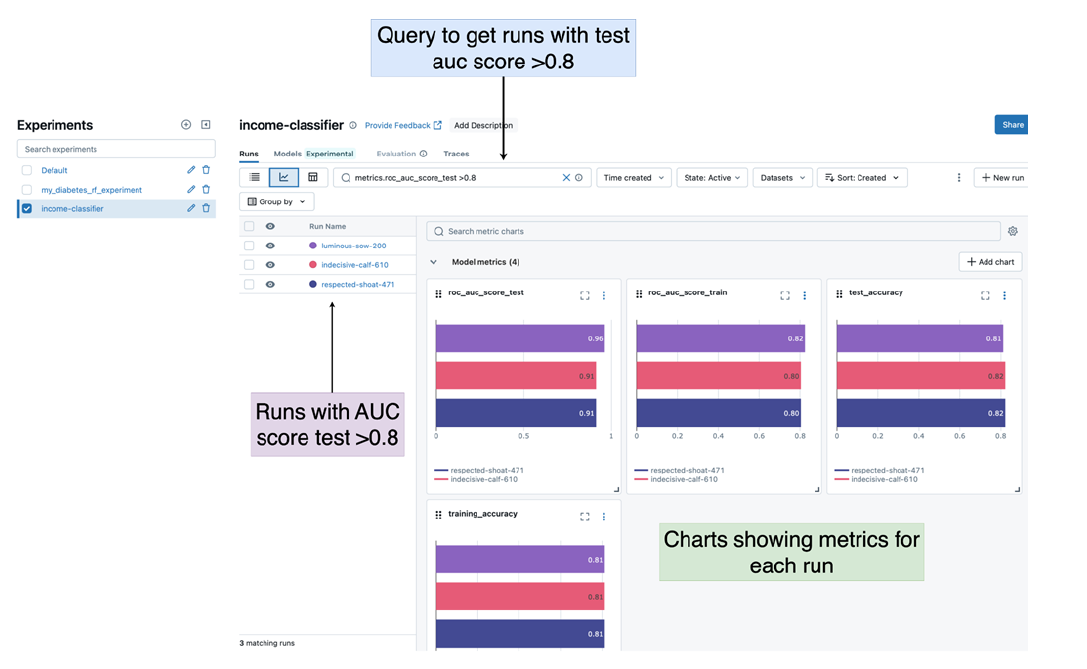

### MLFLOW CLIENT

We can also do this programmatically by using the MLflow client. The MLflow client provides
a programmatic interface for managing and querying machine learning experiments,
tracking metrics, and accessing various functionalities of MLflow. We will use the client to
search for the best model and register it in the MLflow model registry. W

- #A Retrieving run object for a run which has the highest AUC test score
- #B Generating model uri for the retrieved run’s run ID
- #C Registering the model in MLflow model registry

In [43]:
from mlflow import MlflowClient
import mlflow

mlflow_client = MlflowClient()
experiment_name = "income-classifier"

# Get experiment
experiment = mlflow_client.get_experiment_by_name(experiment_name)
if experiment is None:
    raise ValueError(f"Experiment '{experiment_name}' not found")

# Search for best run
run_object = mlflow_client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="metrics.roc_auc_score_test > 0.8",
    max_results=1,
    order_by=["metrics.roc_auc_score_test DESC"],
)[0]

# FIXED: Use "model" as artifact path (default for mlflow.sklearn.log_model)
# Options: "model", "income-classifier", or whatever path you used in log_model()
model_uri = f"runs:/{run_object.info.run_id}/model"

print(f"Registering model from run: {run_object.info.run_id}")
print(f"Test ROC-AUC: {run_object.data.metrics['roc_auc_score_test']:.4f}")

# Register (creates new version if name exists)
registered_model = mlflow.register_model(
    model_uri=model_uri, name="random-forest-classifier"
)

print(f"Registered: {registered_model.name}, version: {registered_model.version}")


Registering model from run: 1a87f74a7c7c420f840fb9de2733b513
Test ROC-AUC: 0.8566


Registered model 'random-forest-classifier' already exists. Creating a new version of this model...
2026/04/10 03:50:05 WARNING mlflow.tracking._model_registry.fluent: Run with id 1a87f74a7c7c420f840fb9de2733b513 has no artifacts at artifact path 'model', registering model based on models:/m-d9d99d0e64d84e52b0d9ba558bbc404b instead
2026/04/10 03:50:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random-forest-classifier, version 2
Created version '2' of model 'random-forest-classifier'.


Registered: random-forest-classifier, version: 2


The model is now registered with the name of random-forest-classifier and can be retrieved
at inference time or if we wish to reproduce the experiment. We can view it in the UI by
clicking the Models tab on the top navigation bar

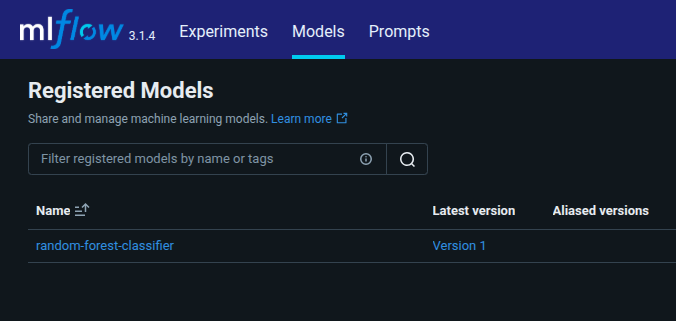

#### FULL real inference with registered model

In [54]:
from mlflow import MlflowClient

client = MlflowClient()

model_name = "random-forest-classifier"

versions = client.search_model_versions(f"name='{model_name}'")

for v in versions:
    uri = f"models:/{model_name}/{v.version}"
    print(uri)


models:/random-forest-classifier/2
models:/random-forest-classifier/1


In [55]:
from mlflow import MlflowClient

client = MlflowClient()

for rm in client.search_registered_models():
    print("Model:", rm.name)

    for v in rm.latest_versions:
        print(f"  models:/{rm.name}/{v.version}")


Model: random-forest-classifier
  models:/random-forest-classifier/2


In [57]:
import mlflow.pyfunc
import pandas as pd

# Load model
model = mlflow.pyfunc.load_model("models:/random-forest-classifier/2")

# Prepare input exactly like training
input_df = pd.DataFrame(X_test.iloc[:5])

# Predict
preds = model.predict(input_df)

print(preds)


[0.5386076  0.35555965 0.74708676 0.7471523  0.33398032]
